<a href="https://colab.research.google.com/github/JuliaMartino/PUC_ML/blob/main/MVP2_ML_Analytics_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Júlia Martino_  
**Matrícula:** _4052025002035_  
**Data:** _10/06/2026_  
**Dataset:** _"Spotify Tracks Dataset"_ https://huggingface.co/datasets/thaeky/spotify-tracks-dataset  
**Tipo de problema:** _Classificação_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O crescimento das plataformas de streaming e dos catálogos digitais tornou a organização automática de músicas um desafio cada vez mais relevante. A classificação manual de grandes volumes de faixas é um processo demorado e sujeito a inconsistências, principalmente porque muitos gêneros musicais apresentam características semelhantes e podem se sobrepor.

A solução pode apoiar sistemas de recomendação musical, organização de bibliotecas digitais e ferramentas de análise de conteúdo em plataformas de streaming, além de servir como exemplo da aplicação de técnicas de classificação supervisionada em problemas multiclasse.

Os principais interessados em soluções desse tipo incluem empresas de streaming musical, desenvolvedores de sistemas de recomendação, pesquisadores da área de ciência de dados aplicada à música e profissionais que trabalham com organização e recuperação de informações musicais.

Esse problema é particularmente relevante porque envolve um grande número de classes (113 gêneros musicais) e gêneros que frequentemente compartilham características acústicas semelhantes, tornando a tarefa de classificação bastante desafiadora. Dessa forma, o projeto permite avaliar como diferentes algoritmos de aprendizado de máquina se comportam diante de um problema real de classificação multiclasse e quais limitações surgem ao utilizar apenas atributos acústicos para representar estilos musicais.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> _Através desse trabalho eu pretendo desenvolver e comparar modelos de aprendizado de máquina capazes de prever o **gênero** de uma música usando as características sonoras disponíveis nessa base de dados._


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação Supervisionada_  

**Justificativa:** _O objetivo é tentar prever a qual gênero uma música pertence através das características sonoras da base de dados._


## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. Os atributos acústicos das músicas (como danceability, energy, loudness e tempo) contêm informação suficiente para permitir que um modelo de aprendizado de máquina identifique padrões associados aos diferentes gêneros musicais.
2. Modelos capazes de representar relações não lineares, como árvores de decisão e Random Forest, apresentarão desempenho superior aos modelos mais simples, devido à complexidade e à sobreposição existente entre os gêneros.
3. A otimização de hiperparâmetros poderá melhorar o desempenho da Random Forest em relação à configuração padrão, aumentando sua capacidade de generalização.

**Critérios de sucesso:**
- Métrica principal: Foi adotado o F1-score ponderado (F1-weighted) como principal métrica de avaliação, por considerar simultaneamente precisão e revocação em um problema multiclasse.
- Resultado mínimo esperado: _ex.: O modelo deveria apresentar desempenho superior ao baseline (DummyClassifier), demonstrando capacidade de aprender padrões presentes nos atributos acústicos.
- Restrição prática:
Além do desempenho, foram considerados: tempo de treinamento compatível com os recursos computacionais disponíveis; utilização de modelos amplamente implementados na biblioteca Scikit-learn; capacidade de generalização para dados não utilizados durante o treinamento; custo computacional compatível com a execução em ambiente Google Colab.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [54]:
# === Setup básico e reprodutibilidade ===
# import os
import sys
import time
import random
import warnings

import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV #, KFold, TimeSeriesSplit

# from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler #, OneHotEncoder
# from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier #, DummyRegressor

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier #, RandomForestRegressor
# from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay #, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score,
    # silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.


In [55]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

A função evaluate_classification foi adaptada pois não usei ROC_AOC nem probabilidades nesse projeto.


In [56]:
# Em evaluate_classification eu retirei ROC_AUC e as probabilidades
# pois não foram usadas nesse projeto

def evaluate_classification(y_true, y_pred):
    """Calcula métricas básicas para classificação."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados
Nessa sessão eu ESCREVER O RESUMO DO QUE FOI FEITO E A BASE DE DADOS QUE FOI CRIADA E PORQUE


## 3.1 Fonte dos dados

Usei a base de dados "Spotify Tracks Dataset", bastante completa em termos de atributos, com informações do ano de 2025.

Link original: https://huggingface.co/datasets/thaeky/spotify-tracks-dataset

Para fazer o trabalho eu baixei o csv e coloquei no repositório do GitHub, é o link que uso para importar a base de dados nesse exercício.

Link no meu GitHub: https://raw.githubusercontent.com/JuliaMartino/PUC_Analise_Dados/refs/heads/main/dataset.csv


O fato do dataset estar artificialmente balanceado para gêneros musicais vai ser propício para esse estudo.

## 3.2 Carga dos dados


In [57]:
# Usando o link para o csv do meu GitHub

url = "https://raw.githubusercontent.com/JuliaMartino/PUC_Analise_Dados/refs/heads/main/dataset.csv"
df = pd.read_csv(url)
print("Impressão dos primeiros resultados:\n\n", df.head())


Impressão dos primeiros resultados:

    Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again 

## 3.3 Visão geral do dataset

O dataset é composto por 114 gêneros de música, 114000 faixas de música e variáveis que indicam título da música, nome do artita, nome do álbum, um índica de popularidade da música e também diversas variáveis numéricas que representam características sonoras das músicas. Algumas dessas características estão numa escala 0 a 1, outras características estão em escalas bem diferentes e algumas são variáveis categóricas nas quais as categorias foram codificadas em números.


### Formato do dataset, existência de dados ausentes e dados duplicados

In [58]:
print("Formato do dataset:", df.shape)

Formato do dataset: (114000, 21)


In [59]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [60]:
print("\nQuais instâncias possuem valores ausentes:\n")

df[df.isna().any(axis=1)]


Quais instâncias possuem valores ausentes:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Essa base de dados possui apenas três valores ausentes. Todos esses valores são do tipo objeto e pertencem a uma mesma instância. **Não será necessário o tratamento**, já que essas três colunas serão excluídas da base de dados do estudo.

In [61]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


### Tipos dos dados

In [62]:
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))


Tipos de dados:


,tipo
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


### Identificando as colunas que não farão parte do estudo:


In [63]:
display(df.sample(5, random_state=SEED))

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113186,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
42819,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
59311,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
91368,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
61000,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


Justificativa:

Eu resolvi focar, nesse estudo, em prever o gênero de uma música através de suas **características sonoras**. Por isso decidi excluir, além de todos os dados não numéricos, também o **índice de popularidade da música**. Alguns gêneros são mais populares que outros e acredito que isso poderia interferir na experiência de saber se essas características sonoras traduzidas em números são capazes de prever como nós entendemos a música culturalmente.

Num outro estudo poderia ser interessante tentar prever a popularidade de uma música através de suas características estéticas.

Uma característica estética ou estilística não numérica e não sonora interessante é o nome da faixa. Eu gostaria de exeperimentar futuramente se alguma característica do nome da faixa é capaz de prever o gênero ou a popularidade de uma música.

In [64]:
print("Essas colunas serão excluídas da base de dados desse estudo:\n")

df.iloc[:, 0:6]



Essas colunas serão excluídas da base de dados desse estudo:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82
...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41


### Descrição do target: track_genre

O TARGET é "track_genre", 114 classes que classificam o gênero das faixas dessa base de dados.

In [65]:
display(df.track_genre)

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic
...,...
113995,world-music
113996,world-music
113997,world-music
113998,world-music


## 3.4 Dicionário de dados

| Coluna | Variável | Tipo | Descrição | Será usada? | Observações |
| --- | --- | --- | --- | --- | --- |
| coluna_1  | track_id | texto | Identificador único da música no Spotify. | não | não é um atributo preditivo |
| coluna_2  | artists          | texto      | Nome do(s) artista(s) que interpreta(m) a música. | não | vou excluir todos os dados não numéricos nesse primeiro momento, mas acredito que não seria um estudo tão interessante, de qualquer maneira |
| coluna_3  | album_name       | texto      | Nome do álbum no qual a música aparece. | não | vou excluir todos os dados não numéricos nesse estudo, mas os álbuns geralmente incluem músicas de estilos parecidos, então não parece muito interessante |
| coluna_4  | track_name       | texto      | Nome da música. | não | seria interessante, numa outra oportunidade, estudar se o nome da música ajuda a prever o gênero ou a popularidade |
| coluna_5  | popularity | numérica | Índice de popularidade da música, de 0 a 100 | não | alguns gêneros musicais são mais populares que outros, resolvi omitir isso e focar nas características estéticas das músicas |
| coluna_6  | duration_ms      | numérica   | Duração da música em milissegundos. | sim | a duração de uma música é uma característica estética relevante para o treinamento |
| coluna_7  | explicit         | categórica | Indica se a música possui conteúdo explícito (verdadeiro ou falso). | sim | se a música é explícita é uma característica estética relevante para o treinamento |
| coluna_8  | danceability     | numérica   | Índice de dançabilidade entre 0,0 e 1,0. | sim | dançabilidade é uma característica estética relevante para o treinamento |
| coluna_9  | energy           | numérica   | Índice entre 0,0 e 1,0 que representa a intensidade e a energia percebida da música. | sim | a intensidade da música é uma característica estética relevante para o treinamento |
| coluna_10 | key              | categórica | Escala musical codificada como número inteiro (ex.: 0 = C, 1 = C♯/D♭). -1 = não identificada. | sim | a escala é uma característica estética relevante para o treinamento |
| coluna_11 | loudness         | numérica   | Volume médio da música em decibéis (dB). | sim | o volume em dB é interessante para esse treinamento |
| coluna_12 | mode             | categórica | Indica se a música está em tonalidade maior (1) ou menor (0). | sim | o tom da música é uma característica estética relevante para o treinamento |
| coluna_13 | speechiness      | numérica   | Índice entre 0,0 e 1,0 que mede a presença de palavras faladas na faixa. | sim | se a música é mais cantada ou falada é uma característica estética relevante para o treinamento |
| coluna_14 | acousticness     | numérica   | Probabilidade de a música ser acústica, variando entre 0,0 e 1,0. | sim | se a música é acústica é uma característica estética relevante para o treinamento |
| coluna_15 | instrumentalness | numérica   | Probabilidade de a música não conter vocais, variando entre 0,0 e 1,0.  | sim | se a música é instrumental é uma característica estética relevante para o treinamento |
| coluna_16 | liveness         | numérica   | Probabilidade de a gravação ter sido realizada ao vivo, variando entre 0,0 e 1,0. | sim | se a gravação está ao vivo é uma característica estética relevante para o treinamento |
| coluna_17 | valence          | numérica   | Representa o sentimento transmitido pela música, de mais negativo (0,0) para mais positivo (1,0). | sim | o sentimento que a música transmite é uma característica estética relevante para o treinamento |
| coluna_18 | tempo            | numérica   | Velocidade estimada da música em batidas por minuto (BPM). | sim | BPM é uma característica estética relevante para o treinamento |
| coluna_19 | time_signature   | categórica | Número de tempos por compasso, normalmente variando entre 3 e 7. | sim | o compasso é uma característica estética relevante para o treinamento |
| target | track_genre      | categórica | Gênero musical atribuído à faixa. | alvo | classe prevista |


## 3.5 Seleção dos dados e criação da primeira versão da base de dados do estudo
Aqui eu crio a primeira versão da base de dados limpa para o estudo, **df_e1**, retirando as colunas que não serão usadas.

In [66]:
df_e = df.iloc[:, 6:]
df_e

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


# 4. Análise exploratória dos dados

A variável alvo possui 113 categorias, o que dificulta algumas visualizações. Optei por começar com as estatísticas básicas e depois usar estratégias que me permitissem selecionar quais variáveis seriam de maior valor no meu estudo, para fazer visualizações apenas com elas.

### Distribuição do target track_genre

A base de dados está artificialmente balanceada para o gênero, o que é propício para o estudo. Mais a frente será usada a estratificação dessas classes para que o estudo se beneficie dessa característica da base de dados.

In [67]:
TARGET = "track_genre"
PROBLEM_TYPE = "classificacao"

print("Distribuição do target:")
display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,contagem
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
trance,1000
trip-hop,1000


,percentual
track_genre,
acoustic,0.88
afrobeat,0.88
alt-rock,0.88
alternative,0.88
ambient,0.88
...,...
techno,0.88
trance,0.88
trip-hop,0.88


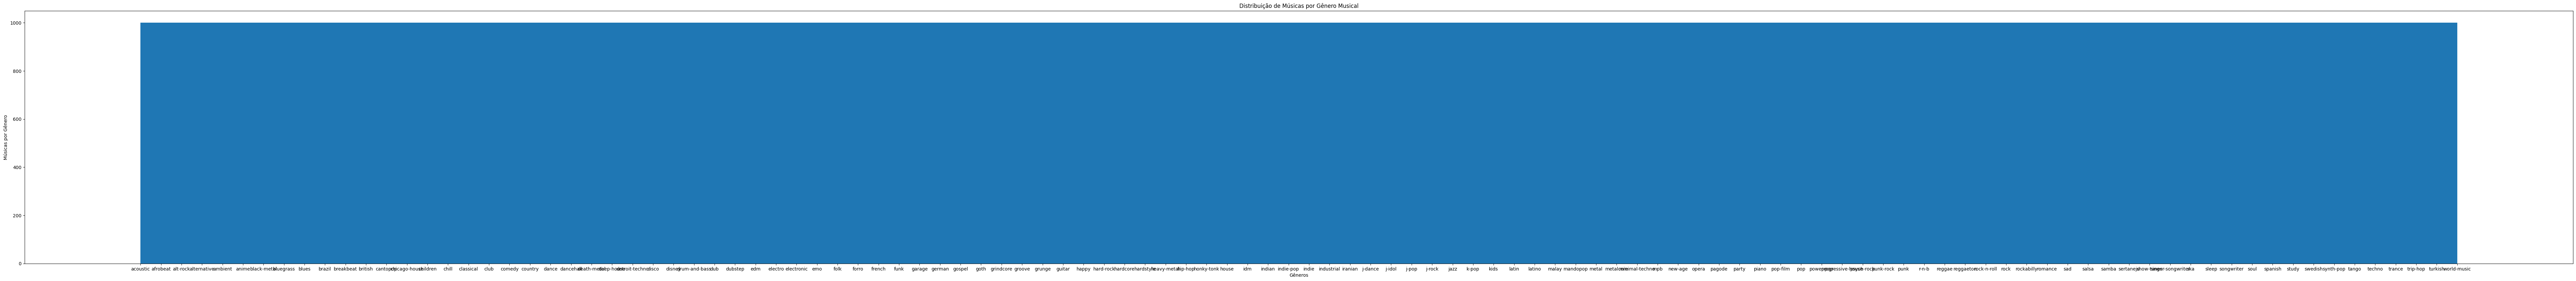

In [68]:
plt.figure(figsize=(100, 10))
plt.hist(df_e['track_genre'], bins=114)
plt.title('Distribuição de Músicas por Gênero Musical')
plt.xlabel('Gêneros')
plt.ylabel('Músicas por Gênero')
plt.show()

A base de dados está artificialmente balanceada para o gênero das músicas, que é o alvo desse projeto. Isso é propício para o estudo.

### Conhecendo o target track_genre

O target desse estudo é a coluna "track_genre" que possui, 114 classes diferentes com exatamente 1000 faixas para cada classe.

Mais à frente no estudo um gênero será excluído, resultando em 113 classes a serem previstas através das qualidades sonoras das faixas.

In [69]:
print(f"Essa base de dados mostra {len(df[TARGET].unique().tolist())} gêneros musicais.\n")

print("São eles:")
print(df[TARGET].unique().tolist())


Essa base de dados mostra 114 gêneros musicais.

São eles:
['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop', 'power-pop', 'progressive-house', 'psych-rock', '

### Identificando faixas que não são músicas

**speechiness** é um valor entre 0.0 e 1.0 que mostra a probabilidade de uma faixa ser uma faixa falada, como uma história ou a gravação de um podcast.

Para essa investigação usei a base de dados inicial, **df**, pois informações como os nomes das músicas, artistas e álbuns seriam úteis,

Investigando esse índice eu descobri que essa base de dados continha muitas faixas que não são músicas. Identifiquei que um gênero específico continha mais instâncias ligadas a probabilidade alta de 'speechiness', o gênero 'comedy'.

Então para esse estudo removi o gênero 'comedy' da base de dados, criando a versão **df_e2**

In [70]:
df[df['speechiness'] > 0.66][['artists', 'track_name', 'album_name', 'track_genre', 'speechiness']]

,artists,track_name,album_name,track_genre,speechiness
1321,Afrocidade,Vivão (vinheta),Vivão,afrobeat,0.924
1492,Jorge Drexler,Fractura de escafoides tarsiano derecho - Cara B,Cara B,afrobeat,0.868
4073,Mohan;Murali;Chandiran,Varraaru Vaarraaru Yaaru Varraaru,Em Magan,ambient,0.761
9152,Sant;Stau,O Que Separa os Homens dos Meninos,"O Que Separa os Homens dos Meninos, Vol. 1",brazil,0.868
9769,Racionais MC's,De Volta À Cena,"Nada Como um Dia Após o Outro Dia, Vol. 1 & 2",brazil,0.853
...,...,...,...,...,...
105313,Left spectrum of the brain,Brainstem,Brainstem,study,0.743
105731,Sless Praismo,Anoroc,"Experimentals, Pt. 3",study,0.729
110148,Armin van Buuren,A State Of Trance (ASOT 1090) - Interview with...,ASOT 1090 - A State Of Trance Episode 1090,trance,0.830
110195,Armin van Buuren,A State Of Trance (ASOT 1090) - Interview with...,ASOT 1090 - A State Of Trance Episode 1090,trance,0.738


Fiquei com receio de simplesmente retirar do estudo as linhas que estivessem acima de 0.66 em speechiness, porque "De Volta à Cena" é uma música dos Racionais e isso indica que provavelmente essa métrica não é tão precisa e acabaria excluindo algumas músicas, principalmente de rap.

Organizei a tabela em ordem decrescente de 'speechiness' para ver se tinha algum insight:

In [71]:
df[df['speechiness'] > 0.66].sort_values('speechiness', ascending=False)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18152,18152,5j7NfGi2DdRJU6Zj7fSiWL,Tenacious D,Post-Apocalypto,turd whistle,26,39426,True,0.630,0.249,...,-14.952,1,0.965,0.3530,0.000000,0.193,0.7390,172.243,3,comedy
18530,18530,2qOJ2ucNveZ8Di2GVWCBFr,Patton Oswalt,Talking for Clapping,Less and Less Radical,23,207619,True,0.650,0.461,...,-18.317,1,0.963,0.8480,0.000000,0.732,0.3650,50.324,4,comedy
18504,18504,2LEkBYeP1mmlcoJmAl1LNF,Tom Papa,Human Mule,The Real World,22,68758,False,0.537,0.548,...,-15.100,0,0.963,0.7360,0.000000,0.745,0.7300,179.403,3,comedy
18666,18666,09YownXjN4uwke2gAtMtE2,Tom Papa,Human Mule,Angry Young Men,21,136820,False,0.587,0.558,...,-14.645,0,0.962,0.7950,0.000000,0.807,0.5590,88.127,4,comedy
18663,18663,3JLsjVkdmrjrbvP1Uiu4IV,Tom Papa,Human Mule,The Human Contract,21,339521,False,0.617,0.592,...,-13.854,1,0.962,0.7210,0.000000,0.752,0.4650,90.721,4,comedy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18931,18931,6lj42oTGDEXKgRBZeY5PSJ,Bruce Bruce,Losin' It,Opening,21,53286,True,0.389,0.595,...,-15.284,0,0.673,0.7600,0.000003,0.669,0.4790,96.998,4,comedy
18358,18358,6MxBErMlx7n16aJNbPVPFD,Billy Gardell,Halftime,Encore,23,151253,True,0.503,0.919,...,-12.125,1,0.668,0.4480,0.000000,0.514,0.0615,115.911,4,comedy
15978,15978,4Uhty1kvytzqhwoLO2CVoi,Tristam;Braken,Flight,Flight,57,219428,False,0.433,0.758,...,-5.736,1,0.662,0.0409,0.000026,0.102,0.2200,87.402,4,chill
29164,29164,4Uhty1kvytzqhwoLO2CVoi,Tristam;Braken,Flight,Flight,57,219428,False,0.433,0.758,...,-5.736,1,0.662,0.0409,0.000026,0.102,0.2200,87.402,4,dubstep


Eu achei interessante que existe um gênero chamado "comedy" que não parece ser um gênero musical. Resolvi investigar isso, então filtrei por gênero "comedy":

In [72]:
df[df['track_genre'] == 'comedy'].sort_values('speechiness', ascending=False)[['artists', 'track_name', 'album_name', 'speechiness']]

,artists,track_name,album_name,speechiness
18152,Tenacious D,turd whistle,Post-Apocalypto,0.9650
18530,Patton Oswalt,Less and Less Radical,Talking for Clapping,0.9630
18504,Tom Papa,The Real World,Human Mule,0.9630
18666,Tom Papa,Angry Young Men,Human Mule,0.9620
18432,Robert Schimmel,Chemotherapy,Life Since Then,0.9620
...,...,...,...,...
18396,Linda P,Støttesang til Realititydeltagerne,Just Divorced,0.0294
18526,Stephen Lynch,HermAphrodite,A Little Bit Special,0.0292
18826,"""Weird Al"" Yankovic",Good Enough for Now,Polka Party,0.0291
18838,Steve Martin;Steep Canyon Rangers,"Go Away, Stop, Turn Around, Come Back",Rare Bird Alert,0.0278


Nomes de comediantes conhecidos aparecem. Mas eu sei que Tenacious D, por exemplo, tem músicas, e que o Steve Martin fez esse álbum, "Rare Bird Alert" com músicos conhecidos.

Resolvi filtrar o gênero 'comedy' para ver quantas músicas desse gênero tinham 'speechiness' > 0.66.

In [73]:
df[(df['track_genre'] == 'comedy') & (df['speechiness'] > 0.66)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18019,18019,7dx3l9Q5BpBYrOmu3su1JF,Mitch Fatel,Miniskirts and Muffins - EP,Sloppy Drunk,30,79093,True,0.443,0.865,...,-13.341,1,0.927,0.925,0.000504,0.776,0.3060,145.511,3,comedy
18020,18020,1mGPRNd31oB74oEZ22s4Sn,Katt Williams,Pimp Chronicles Pt.1,Stop Trippin,30,155280,True,0.653,0.904,...,-12.741,0,0.920,0.782,0.000000,0.805,0.3790,90.105,3,comedy
18021,18021,6A3mLcrJtbaMM8n1ONxMFa,Jim Norton,Despicable - EP,What Sex Is That Thing?,31,88533,True,0.488,0.954,...,-11.292,0,0.928,0.833,0.000000,0.851,0.0766,102.926,5,comedy
18023,18023,0m5PV2y8rtKL6PhX9JvxGg,Jim Norton,Despicable - EP,"The Bridge, Lol",30,56106,True,0.643,0.653,...,-11.670,1,0.955,0.819,0.000000,0.900,0.7190,85.666,4,comedy
18024,18024,1JjQ0vNVatTsOYL6plWAo9,Jeff Foxworthy,We've Been Thinking,Facts of Life,29,606023,False,0.581,0.879,...,-10.652,1,0.947,0.794,0.000000,0.963,0.1440,106.192,4,comedy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18991,18991,6qZHDW6l4Szjjh0r8gyL3O,Big Jay Oakerson,I Promised Myself I Wouldnt Ask,Earn Your Creams,20,188212,True,0.349,0.890,...,-9.574,1,0.847,0.856,0.000002,0.812,0.5820,82.455,4,comedy
18992,18992,5wZHyWxGn37PBQm3XWQXMf,Larry The Cable Guy,Remain Seated,Bus Rides & Roller Coasters,20,192603,False,0.543,0.746,...,-12.087,1,0.959,0.713,0.000000,0.338,0.2960,86.382,3,comedy
18994,18994,7qpPZcSLlr1jJKpSeHzwB6,Eugene Mirman,An Evening of Comedy in a Fake Underground Lab...,Christian Mingle and My Childhood Notebook,20,374506,True,0.555,0.927,...,-5.424,1,0.907,0.765,0.000000,0.799,0.3950,80.742,3,comedy
18998,18998,3ZLp1i7FSPn05tuvnuXaAp,Ron White,Truckstop Comedy,Gay Rights,20,827146,True,0.595,0.576,...,-14.405,1,0.908,0.926,0.000000,0.680,0.4170,110.170,4,comedy


Nessa base de dados cada gênero tem 1000 faixas. No gênero 'comedy' 767 faixas tem speechiness > 0.66. Ou seja, 76,7% das faixas provavelmente não são músicas.

**Com base nisso eu resolvi excluir o gênero 'comedy' desse estudo, modificando a df_e.**

In [74]:
df_e = df_e[~((df['track_genre'] == 'comedy'))]

# Corrected line to display the original df, excluding the 'comedy' genre, sorted by speechiness
df[df['track_genre'] != 'comedy'].sort_values('speechiness', ascending=False)[['artists', 'track_name', 'album_name', 'track_genre', 'speechiness']]

,artists,track_name,album_name,track_genre,speechiness
66905,The Jamborees,Six Socks,Bedtime Stories,kids,0.957
66956,The Jamborees,Great Bear,Bedtime Stories,kids,0.953
66711,The Jamborees,The Money Bunny,Bedtime Stories,kids,0.949
66521,Babyboomboom,This Little Piggy (Zhè Zhī Xiǎo Xhū),English and Mandarin Chinese,kids,0.946
14777,Peppa Pig Stories,Grandpa Pig's Train to the Rescue,Grandpa Pig's Train to the Rescue,children,0.943
...,...,...,...,...,...
101841,Granular,Pink Noise For Sleep 9,Pink Noise For Sleep,sleep,0.000
101059,Sleep Baby Sleep;White Noise Babies;White Nois...,Soothing Brown Noise Waves,Soothing Brown Noise Waves and Calming Ambient...,sleep,0.000
101060,Water Sound Natural White Noise,Noise for Restless Kids,White Noise Spa – Calming Noises,sleep,0.000
101875,White Noise Therapy,Hidden Waterfall,White Noise Therapy Vol. 1,sleep,0.000


Olhando o resultado e atentando para o álbum "Bedtime Stories" resolvi investigar se existia algum outro gênero que tivesse grande incidência de faixas com 'speechiness' > 0.66, como por exemplo algo ligado a histórias para crianças dormirem:

In [75]:
display(
    df_e[df_e['speechiness'] > 0.66]
    .sort_values('speechiness', ascending=False)
    .value_counts('track_genre')
    .head(10)
)

,count
track_genre,
kids,11
children,10
show-tunes,10
funk,9
jazz,5
chill,4
j-dance,4
garage,4
sad,3


Provavelmente existem algumas histórias na base de dados, mas eu resolvi não desbalancear e nem excluir totalmente os gêneros. Eu teria que ter esse refinamento se eu mesma fosse buscar os dados no Spotify, aí sim excluindo as faixas que tivessem 'speechiness' > 0.66 totalmente da base de dados.

### Estatísticas descritivas

A análise descritiva mostra que **as variáveis apresentam escalas bastante diferentes**. "duration_ms" está em milissegundos, ou seja, os números variam na ordem de centenas de milhares. Enquanto isso vários atributos estão numa escala que vai de 0 a 1.

No geral, as estatísticas descritivas indicam um conjunto de dados heterogêneo, com atributos apresentando amplitudes e distribuições distintas.

Primeiro excluí o target, track_genre, deixando apenas as variáveis numéricas.

In [76]:
df_e.iloc[:, :14]


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [77]:
df_e.iloc[:, :14].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,113000.0,228052.146832,107034.153205,0.000,174333.00000,213000.000000,261413.0000,5237295.000
danceability,113000.0,0.566708,0.174018,0.000,0.45500,0.580000,0.6950,0.985
energy,113000.0,0.640865,0.251972,0.000,0.47100,0.684000,0.8540,1.000
key,113000.0,5.311398,3.562113,0.000,2.00000,5.000000,8.0000,11.000
loudness,113000.0,-8.239505,5.027672,-49.531,-9.97700,-6.985000,-4.9920,4.532
mode,113000.0,0.636832,0.480915,0.000,0.00000,1.000000,1.0000,1.000
speechiness,113000.0,0.078714,0.080183,0.000,0.03580,0.048600,0.0829,0.957
acousticness,113000.0,0.311268,0.331053,0.000,0.01650,0.165000,0.5870,0.996
instrumentalness,113000.0,0.157426,0.310573,0.000,0.00000,0.000046,0.0525,1.000
liveness,113000.0,0.209587,0.184717,0.000,0.09770,0.131000,0.2700,1.000


A análise descritiva mostra que **as variáveis apresentam escalas bastante diferentes**. "duration_ms" está em milissegundos, ou seja, os números variam na ordem de centenas de milhares. Enquanto isso vários atributos estão numa escala que vai de 0 a 1.

Os atributos danceability, energy e valence apresentam médias intermediárias (entre aproximadamente 0,47 e 0,64), sugerindo boa variabilidade entre as músicas do conjunto. Já speechiness possui média baixa (0,079), indicando que a maior parte das faixas contém pouca fala.

A variável instrumentalness apresenta mediana praticamente igual a zero, enquanto sua média é significativamente maior (0,157). Isso sugere uma distribuição bastante assimétrica, com muitas músicas vocais e uma parcela menor de faixas predominantemente instrumentais.

Observa-se ainda que time_signature possui pouca variabilidade, concentrando-se principalmente no valor 4, enquanto key distribui-se entre as doze tonalidades musicais.

No geral, as estatísticas descritivas indicam um conjunto de dados heterogêneo, com atributos apresentando amplitudes e distribuições distintas.

### Histogramas

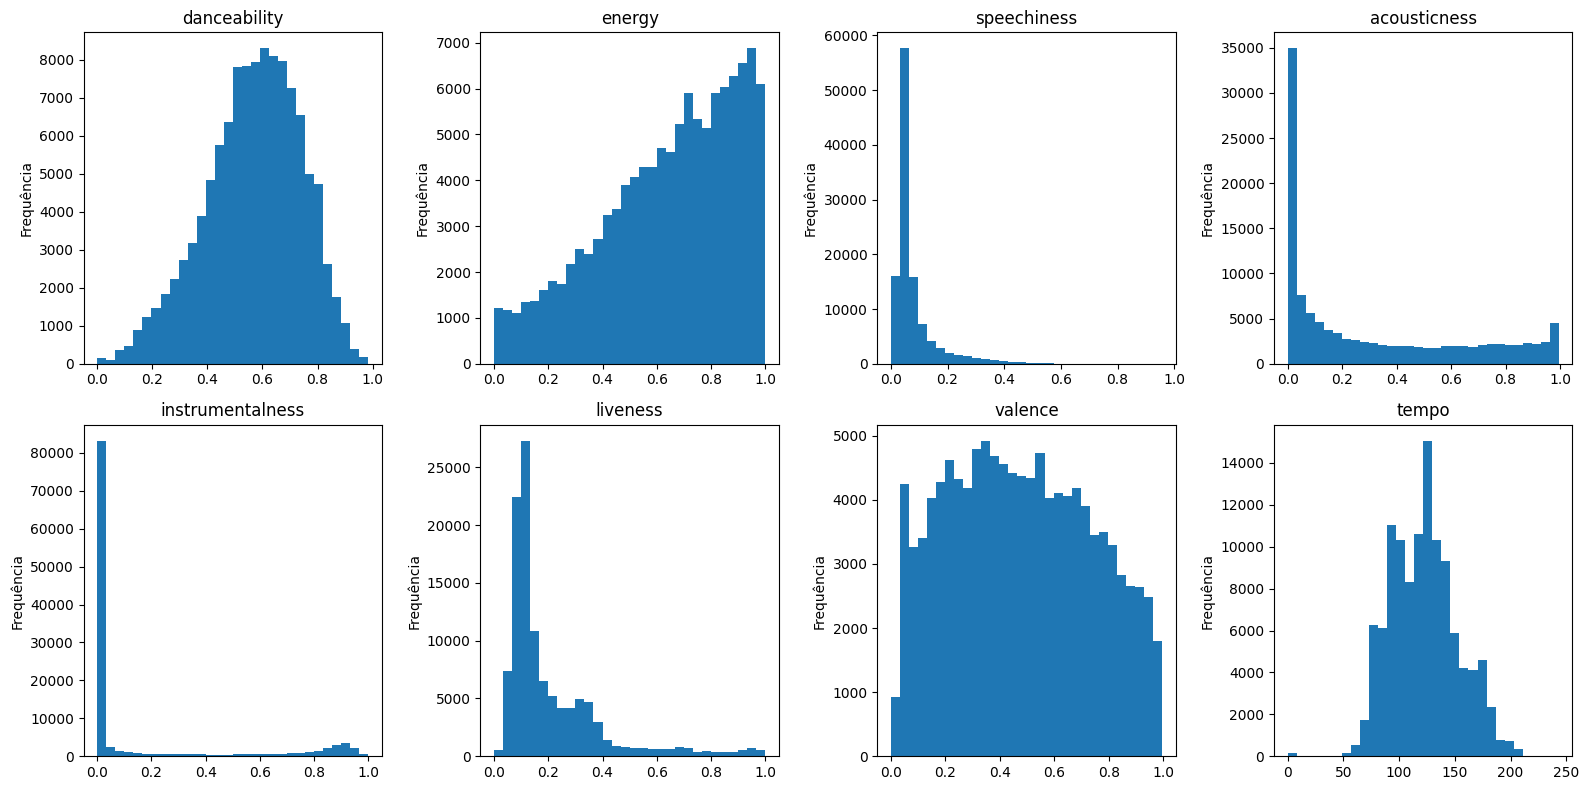

In [78]:
histogramas = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, histo in zip(axes.flat, histogramas):
    ax.hist(df_e[histo], bins=30)
    ax.set_title(histo)
    ax.set_xlabel('')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

Os atributos danceability, energy e valence apresentam médias intermediárias (entre aproximadamente 0,47 e 0,64), sugerindo boa variabilidade entre as músicas do conjunto. Já speechiness possui média baixa (0,079), indicando que a maior parte das faixas contém pouca fala.

A variável instrumentalness apresenta mediana praticamente igual a zero, enquanto sua média é significativamente maior (0,157). Isso sugere uma distribuição bastante assimétrica, com muitas músicas vocais e uma parcela menor de faixas predominantemente instrumentais.

Observa-se ainda que time_signature possui pouca variabilidade, concentrando-se principalmente no valor 4, enquanto key distribui-se entre as doze tonalidades musicais.

### Boxplot Variáveis

Fiz uma visualização de caixas para todas as variáveis que estão na escala 0 a 1: danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence.

Existem outros dois boxplots depois do resultado de Mutual Information e Random Forest terem indicado quais poderiam ser as variáveis mais interessantes para prever o gênero.

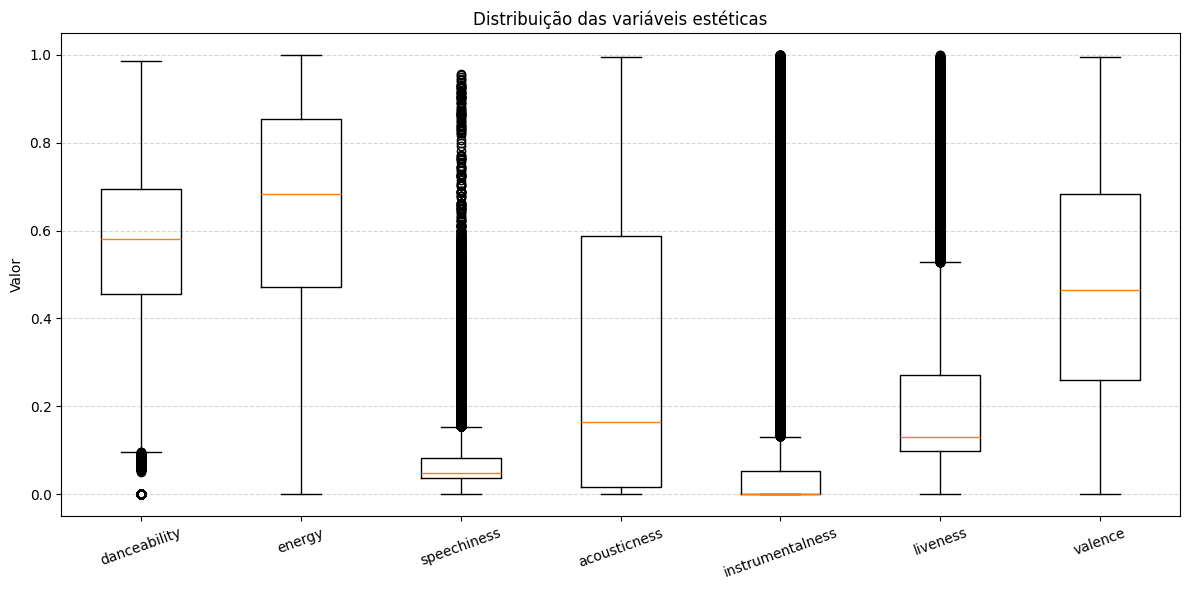

In [79]:
mesma_escala = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence'
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    [df_e[col] for col in mesma_escala],
    labels=mesma_escala,
    showfliers=True
)

plt.title('Distribuição das variáveis estéticas')
plt.ylabel('Valor')
plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Matriz de Correlação
Eu fiz a Matriz de Correlação excluindo o target, gênero, pois são classes e não uma série.
Fiz dessa forma para ver se existia algum par reduntante de variáveis. Para não precisar instalar o Seaborn apenas para usar o heatmap filtrei a matriz para resultados maiores que 0.7 ou menores que -0.7

In [80]:
print("\nMatriz de Correlação:")

# Usei a df apenas com os valores numéricos,
# excluindo o target, pois é classe, para fazer a correlação entre os valores numéricos e ver se existe redundância entre variáveis

correlacao = df_e.iloc[:, :14].corr()
display(correlacao)


Matriz de Correlação:


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
duration_ms,1.000000,-0.068853,-0.073563,0.058468,0.008645,-0.004004,-0.036599,-0.085592,-0.105631,0.125247,0.009868,-0.154197,0.024974,0.016652
explicit,-0.068853,1.000000,0.124501,0.095338,0.006577,0.119110,-0.041908,0.260513,-0.121525,-0.097518,-0.010890,-0.002438,0.010935,0.052796
danceability,-0.073563,0.124501,1.000000,0.135803,0.036558,0.260131,-0.069857,0.146521,-0.172304,-0.185848,-0.134316,0.477671,-0.051193,0.211378
energy,0.058468,0.095338,0.135803,1.000000,0.048870,0.764716,-0.078769,0.165145,-0.745537,-0.181524,0.183816,0.262020,0.252210,0.192755
key,0.008645,0.006577,0.036558,0.048870,1.000000,0.039097,-0.136117,0.032414,-0.040603,-0.007178,-0.000398,0.033870,0.011021,0.015182
loudness,-0.004004,0.119110,0.260131,0.764716,0.039097,1.000000,-0.041311,0.122395,-0.591846,-0.437984,0.091709,0.280425,0.211270,0.192345
mode,-0.036599,-0.041908,-0.069857,-0.078769,-0.136117,-0.041311,1.000000,-0.070876,0.095169,-0.049461,0.012115,0.022307,0.001554,-0.024118
speechiness,-0.085592,0.260513,0.146521,0.165145,0.032414,0.122395,-0.070876,1.000000,-0.110710,-0.081312,0.065665,0.064822,0.086679,0.064484
acousticness,-0.105631,-0.121525,-0.172304,-0.745537,-0.040603,-0.591846,0.095169,-0.110710,1.000000,0.110644,-0.053392,-0.106194,-0.202098,-0.171247
instrumentalness,0.125247,-0.097518,-0.185848,-0.181524,-0.007178,-0.437984,-0.049461,-0.081312,0.110644,1.000000,-0.071918,-0.326003,-0.053879,-0.087550


Para não ter que instalar o Seaborn apenas para fazer um heatmap eu filtrei a matriz para mostrar os valores de correlação maiores do que 0.7 ou menores do que -0.7

In [81]:
correlacao[(correlacao > 0.7) | (correlacao < -0.7)]


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
duration_ms,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
explicit,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,NaN,0.764716,NaN,NaN,-0.745537,NaN,NaN,NaN,NaN,NaN
key,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.764716,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mode,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.745537,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
instrumentalness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


Conclusão:

A matriz revela correlação entre 'energy' e 'loudness' de 0.76 e entre 'energy' e 'acousticness' de -0.74. São correlações interessantes, mas que não indicam redundancia de variáveis.

## 4.1 Síntese da análise exploratória

- Através da análise exploratória eu percebi que **existem faixas que não são músicas**. Essas faixas foram identificadas com o gênero "comedy", que foi excluído do estudo atualizando a **df_e** na sessão **"Identificando faixas que não são músicas"**.
- O target está artificialmente balanceado, o que é propício para o projeto.
- Essa base de dados tem três valores ausentes, mas eles não são relevantes para o estudo e estão em colunas que seriam excluídas do projeto de qualquer forma.
- Há variáveis em escala muito diferente, que precisam ser normalizadas caso o modelo exija.
- A grande quantidade de classes (113 gêneros) indicava que a tarefa seria naturalmente desafiadora, tornando improvável a obtenção de altas taxas de acerto apenas com modelos mais simples.
- A elevada sobreposição observada entre diversos gêneros reforçou a decisão de testar modelos mais robustos, como a Random Forest, e de utilizar o F1-score ponderado como principal métrica de avaliação.
- Os atributos acústicos apresentam distribuições complexas e, em muitos casos, há sobreposição entre diferentes gêneros musicais. Isso sugere que relações lineares simples dificilmente seriam suficientes para separar todas as classes. Por esse motivo, modelos capazes de representar relações não lineares, como Decision Tree e principalmente Random Forest, tinham potencial para apresentar melhor desempenho.


# Prévia: Mutual Information e Random Forest

Meu objetivo principal é saber se as variáveis que são classes precisam mesmo entrar no estudo ou se eu posso fazer o estudo usando apenas as variáveis que já estão numa mesma escala e são números contínuos, mais versáteis para os modelos de ML e menos propensos a interpretações erradas pelos modelos. Usei Mutual Information para obter insights sobre quais variáveis parecem interessantes para o estudo e quais parecem ser menos capazes de prever o gênero.

### Prévia: divisão treino e teste

Essa divisão será usada apenas nessa prévia, para o treinamento farei outra.


In [82]:
# Definição do problema para a prévia MI e RF

TARGET = "track_genre"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ['Unnamed: 0']
DATE_COLUMN = None
DROP_COLUMNS = ['track_id', 'artists', 'album_name', 'track_name', 'popularity']

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features_RF1 = [c for c in df_e.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features_RF1))
print("Features:", features_RF1)


Tipo de problema: classificacao
Target: track_genre
Número de features: 14
Features: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


In [83]:
# Divisão de dados para a prévia MI e RF

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X1 = df_e[features_RF1].copy()
    y1 = df_e[TARGET].copy()

    stratify_arg = y1 if PROBLEM_TYPE == "classificacao" else None
    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X1_train.shape, "| Teste:", X1_test.shape)


Treino: (90400, 14) | Teste: (22600, 14)


In [84]:
discrete = [
    col in ['explicit', 'time_signature', 'key', 'mode']
    for col in X1.columns
]

### Mutual Information

In [85]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X1,
    y1,
    discrete_features = discrete,
    random_state = SEED
)

In [86]:
print(mi)

[0.53190325 0.05764433 0.40899366 0.49788752 0.04057696 0.54173083
 0.03367787 0.28905214 0.6244406  0.40972697 0.20983045 0.36479033
 0.59403883 0.05043186]


In [87]:
mi_df = (
    pd.DataFrame({
        'Variável': X1.columns,
        'Mutual Information': mi
    })
    .sort_values('Mutual Information', ascending=False)
)

display(mi_df)

,Variável,Mutual Information
8,acousticness,0.624441
12,tempo,0.594039
5,loudness,0.541731
0,duration_ms,0.531903
3,energy,0.497888
9,instrumentalness,0.409727
2,danceability,0.408994
11,valence,0.364790
7,speechiness,0.289052
10,liveness,0.209830


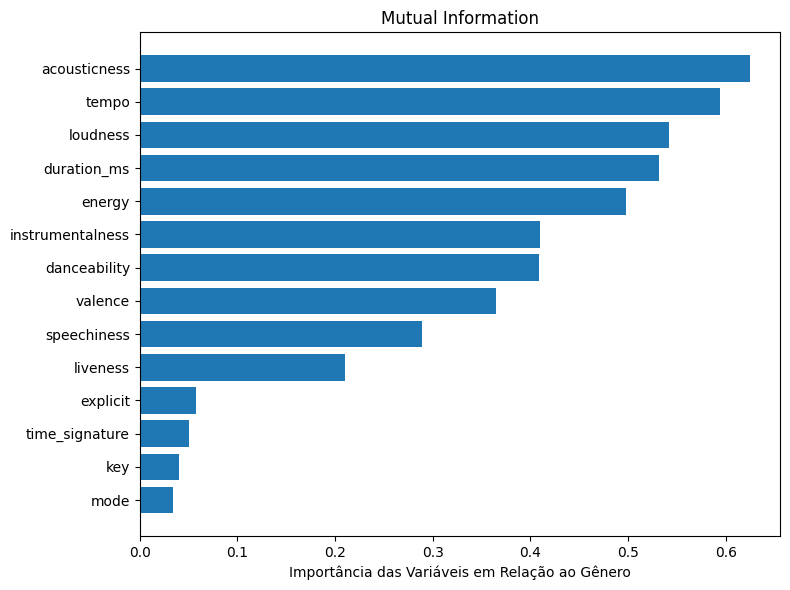

In [88]:
plt.figure(figsize=(8,6))

plt.barh(
    mi_df['Variável'],
    mi_df['Mutual Information']
)

plt.xlabel('Importância das Variáveis em Relação ao Gênero')
plt.title('Mutual Information')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Conclusão MI:
Provavelmente faz sentido retirar as variáveis categóricas e focar nas outras que são mais simples de processar e tem maior valor preditivo.

### Random Forest

Eu desliguei o processamento dessa prévia da Random Forest para liberar RAM. Salvei a tabela com as importâncias em um arquivo CSV e coloquei no GitHub. Esse arquivo CSV foi usado para fazer o estudo quando o processamento dessa RF está desligado.

O resultado dessa prévia confirma o resultado da MI: As variáveis categóricas têm baixo valor preditivo.

In [89]:
RF_EDA = False

In [90]:
if RF_EDA:
  rf = RandomForestClassifier(
      n_estimators = 100,
      n_jobs = 1,
      random_state = SEED,
  )

In [91]:
if RF_EDA:
  print(X1_train.shape)
  print(X1_train.dtypes)
  X1_train.info()
  print(X1_train.memory_usage(deep=True).sum() / 1024**2, "MB")

In [92]:
if RF_EDA:
  rf.fit(X1_train, y1_train)

In [93]:
if RF_EDA:
  importance = pd.DataFrame({
      "Variável": X1_train.columns,
      "Importância": rf.feature_importances_
  })

  importance = importance.sort_values(
     "Importância",
     ascending=False
  )

  display(importance)

Eu usei esse código para salvar a tabela em .csv

In [94]:
# importance.to_csv("rf_feature_importance.csv", index=False)

Fiz o download para o meu computador. Depois salvei o arquivo no repositório do GitHub para que pudesse ser acessado sem precisar rodar a RF, liberando RAM na execução do notebook.

In [95]:
# from google.colab import files
# files.download("rf_feature_importance.csv")

In [96]:
if RF_EDA:
  del rf
  gc.collect()

Aqui eu pego o arquivo .csv com as importâncias obtidas nessa Random Forest e uso para gerar a visualização das importâncias.

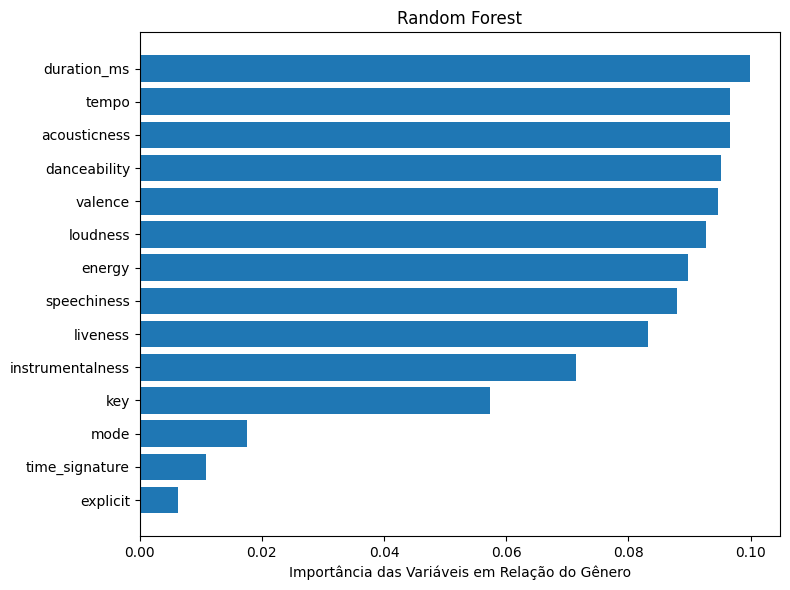

In [97]:
if RF_EDA:

  plt.figure(figsize=(8,6))

  plt.barh(
      importance["Variável"],
      importance["Importância"]
  )

  plt.gca().invert_yaxis()

  plt.xlabel("Importância das Variáveis em Relação do Gênero")
  plt.title("Random Forest")

  plt.tight_layout()
  plt.show()

else:

  url_rf_eda_importance = "https://raw.githubusercontent.com/JuliaMartino/PUC_ML/refs/heads/main/rf_feature_importance.csv"
  rf_eda_importance = pd.read_csv(url_rf_eda_importance)

  plt.figure(figsize=(8,6))

  plt.barh(
      rf_eda_importance["Variável"],
      rf_eda_importance["Importância"]
  )

  plt.gca().invert_yaxis()

  plt.xlabel("Importância das Variáveis em Relação do Gênero")
  plt.title("Random Forest")

  plt.tight_layout()
  plt.show()



A pévia de Random Forest confirma que as variáveis categóricas não são de tanto valor preditivo.

In [98]:
# Comparando MI e RF MEDIA

comparacao_MI_RF = pd.merge(
    mi_df,
    rf_eda_importance,
    on="Variável"
)

comparacao_MI_RF["Ranking MI"] = (
    comparacao_MI_RF["Mutual Information"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

comparacao_MI_RF["Ranking RF"] = (
    comparacao_MI_RF["Importância"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

comparacao_MI_RF["Media"] = (
    comparacao_MI_RF["Ranking RF"] +
    comparacao_MI_RF["Ranking MI"] /2
)

comparacao_MI_RF = comparacao_MI_RF.sort_values("Media")

display(comparacao_MI_RF)

,Variável,Mutual Information,Importância,Ranking MI,Ranking RF,Media
1,tempo,0.594039,0.096614,2,2,3.0
3,duration_ms,0.531903,0.099811,4,1,3.0
0,acousticness,0.624441,0.096578,1,3,3.5
2,loudness,0.541731,0.092754,3,6,7.5
6,danceability,0.408994,0.095144,7,4,7.5
7,valence,0.364790,0.094708,8,5,9.0
4,energy,0.497888,0.089801,5,7,9.5
8,speechiness,0.289052,0.087986,9,8,12.5
5,instrumentalness,0.409727,0.071361,6,10,13.0
9,liveness,0.209830,0.083124,10,9,14.0


### Boxplots Variáveis Relevantes

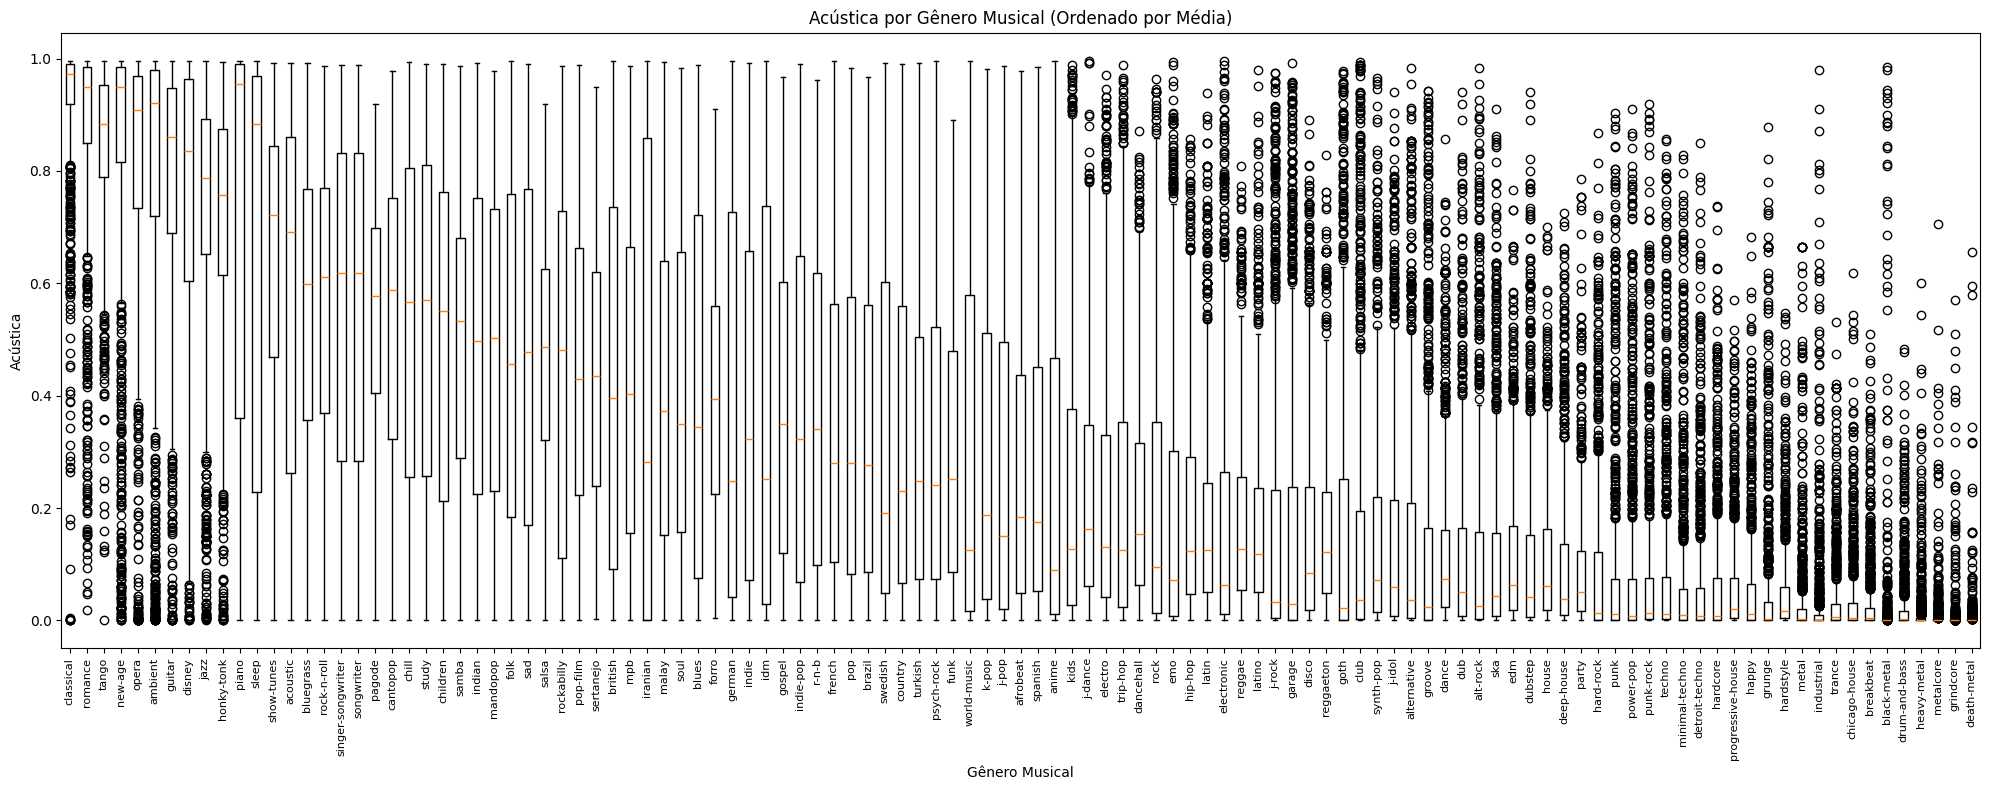

In [99]:
# Para ordenar - calculando as médias de 'acousticness' para cada gênero
genre_mean_acousticness = df_e.groupby('track_genre')['acousticness'].mean()

# Ordenando os gêneros pelas médias de 'acousticness'
sorted_genres = genre_mean_acousticness.sort_values(ascending=False).index.tolist()

# Boxplot
boxplot_data = [df_e[df_e['track_genre'] == genre]['acousticness'].values for genre in sorted_genres]
genre_labels = sorted_genres

plt.figure(figsize=(20, 8))
plt.boxplot(boxplot_data, labels=genre_labels)
plt.title('Acústica por Gênero Musical (Ordenado por Média)')
plt.xlabel('Gênero Musical')
plt.ylabel('Acústica')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

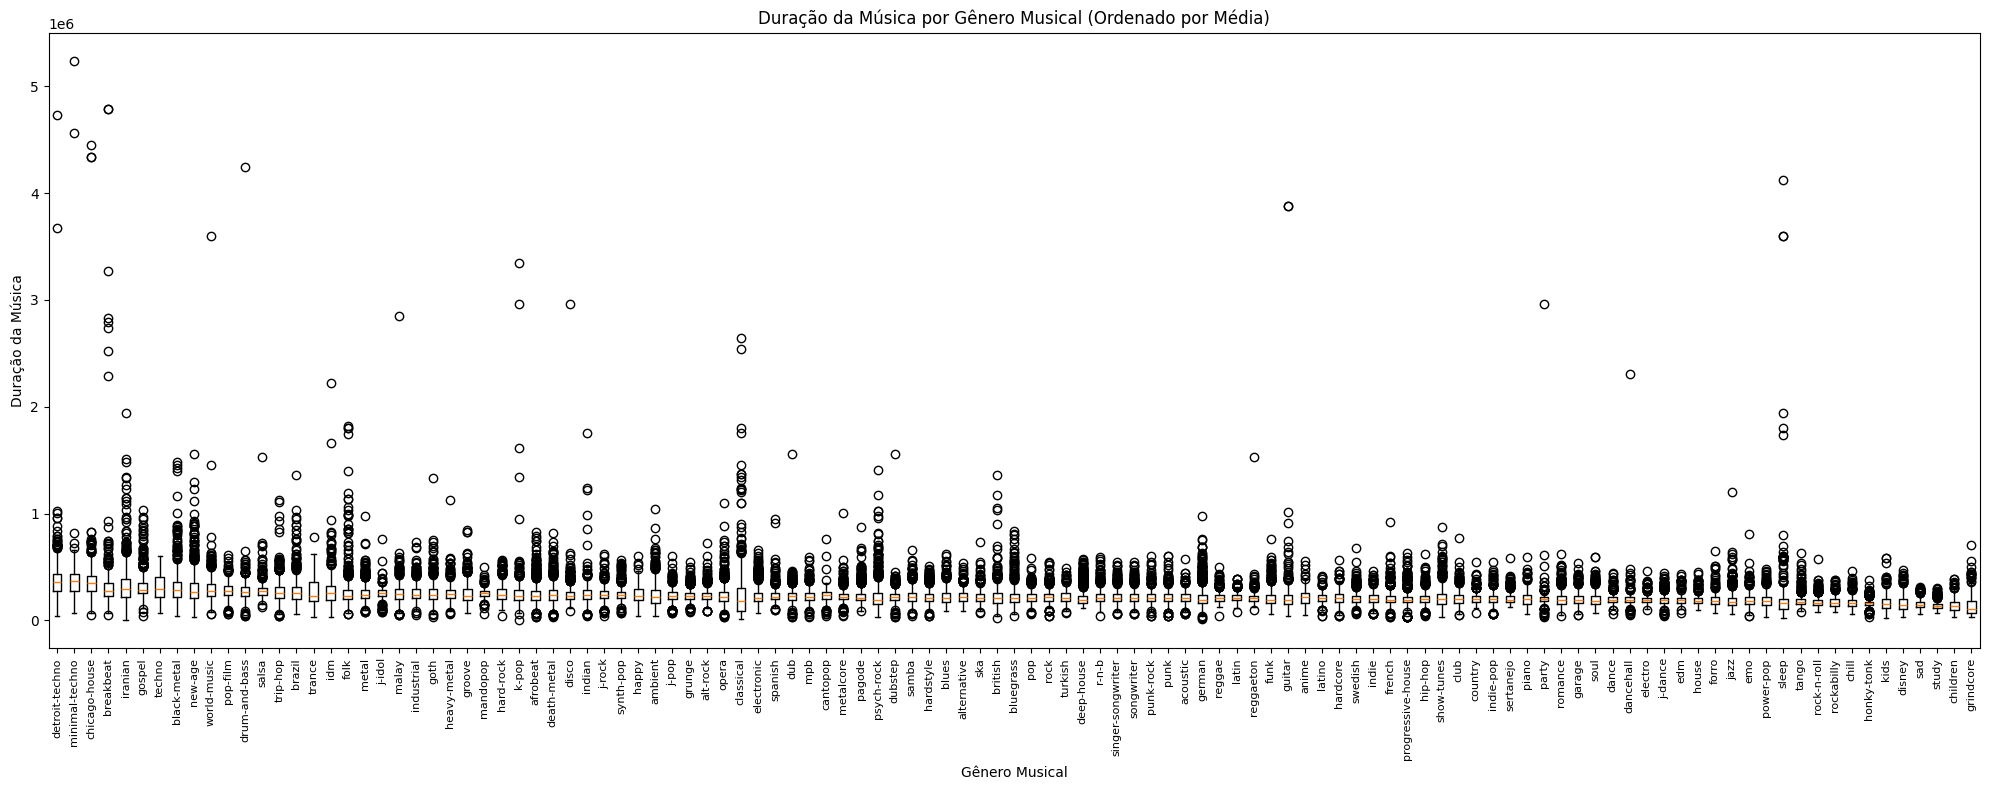

In [100]:
# Para ordenar - calculando as médias de 'duration_ms' para cada gênero
genre_mean_duration = df_e.groupby('track_genre')['duration_ms'].mean()

# Ordenando os gêneros pelas médias de 'tempo'
sorted_genres = genre_mean_duration.sort_values(ascending=False).index.tolist()

# Boxplot
boxplot_data = [df_e[df_e['track_genre'] == genre]['duration_ms'].values for genre in sorted_genres]
genre_labels = sorted_genres

plt.figure(figsize=(20, 8))
plt.boxplot(boxplot_data, labels=genre_labels)
plt.title('Duração da Música por Gênero Musical (Ordenado por Média)')
plt.xlabel('Gênero Musical')
plt.ylabel('Duração da Música')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

Eu achei interessante "duration" ter ficado em segundo lugar em importância e ter resultado num gráfico tão homogêneo. Eu esperava algo mais parecido com o gráfico de "acústica" para valores de alta importância preditiva.

### Conclusão: exclusão de 4 colunas

Amparada nessa prévia eu decidi excluir as quatro variáveis categóricas do estudo: **'key', 'time_signature', 'mode' e 'explicit'**, por terem ficado nos quatro últimos lugares de relevância em relação ao gênero da música.
Assim ficam sobrando para o estudo 10 variáveis mais relevantes.

# 5. Preparação dos dados e divisão treino/teste

Com base na decisão de estudar apenas as características sonoras das músicas, as colunas com os nomes dos artistas, de álbuns e das faixas, foram excluídas. Pelo mesmo motivo a coluna com índice de popularidade da música foi excluída.

As colunas com informações categóricas de acordes, assinatura de tempo, modo (maior ou menor) e se a faixa é explícita foram excluídas do estudo por apresentarem baixo valor preditivo e uma maior complexidade de tratamento.

In [101]:
# === Configuração do problema ===

TARGET = "track_genre"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ['Unnamed: 0']
DATE_COLUMN = None
DROP_COLUMNS = ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'key', 'time_signature', 'mode', 'explicit']

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df_e.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: track_genre
Número de features: 10
Features: ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [102]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df_e[features].copy()
    y = df_e[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (90400, 10) | Teste: (22600, 10)


## 5.1 Justificativa da divisão

Foi utilizada inicialmente a estratégia holdout, separando o conjunto de dados em treinamento e teste. Essa abordagem é adequada porque o objetivo principal era comparar diferentes modelos utilizando um conjunto de teste independente, permitindo avaliar sua capacidade de generalização.

O conjunto contém aproximadamente 113 mil músicas, sendo utilizada uma divisão de 80% para treinamento e 20% para teste.

Essa **proporção fornece um volume suficiente de exemplos para o treinamento dos modelos, preservando ao mesmo tempo um conjunto de teste representativo** para a avaliação final.

Como o problema envolve 113 gêneros musicais, foi utilizada a opção stratify=y no train_test_split, **preservando a proporção de cada gênero nos conjuntos de treinamento e teste**.

Da mesma forma, durante a otimização foi utilizado StratifiedKFold, assegurando que cada partição da validação cruzada mantivesse essa distribuição.

Primeiramente, o conjunto de teste foi separado antes da etapa de treinamento dos modelos, permanecendo completamente isolado durante o processo de aprendizado.

Além disso, a otimização de hiperparâmetros foi realizada exclusivamente sobre o conjunto de treinamento, utilizando validação cruzada. Dessa forma, o conjunto de teste foi utilizado apenas uma única vez, na avaliação final do modelo selecionado.

Essa **estratégia reduz o risco de vazamento** de dados e permite obter uma estimativa mais confiável da capacidade de generalização do modelo.

# 6. Pré-processamento e pipeline

Será utilizada uma Pipeline apenas para o modelo KNN, integrando a padronização dos atributos e o treinamento do classificador. Essa abordagem garante que a padronização seja ajustada exclusivamente com os dados de treinamento e aplicada posteriormente ao conjunto de teste, evitando vazamento de informações (data leakage).

Os demais modelos, baseados em árvores, não passaram pela padronização.

Do estudo foram excluídas todas as variáveis categóricas por possuírem provável baixa relação com o target 'track_genre', como concluído depois das prévias com Mutual Information e Random Forest.


In [103]:
# Identificação automática simples de colunas numéricas e categóricas.
# Eu limpei a base de dados de todas as variáveis categóricas pois elas não ajudavam a prever o TARGET.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Apenas o modelo KNN precisa de pipeline para transformar os dados
# eu coloquei adiante

#Não existe nenhuma variável categórica, apenas numéricas
print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Colunas categóricas: []


## 6.1 Decisões de pré-processamento

- Não foi necessária imputação de dados: a base de dados inicial tinha apenas três valores faltantes, justamente em colunas que não serão usadas nesse estudo.
- A padronização será aplicada apenas para o modelo KNN, que é sensível à escala das variáveis. Modelos baseados em árvores não passaram pela padronização, já que realizam divisões por limiares e não utilizam medidas de distância.
- A Pipeline do KNN está definida na próxima etapa.
- As variávies categóricas foram excluídas do estudo por terem apresentado, após prévia com Mutual Information e Random Forest, baixo valor preditivo combinada a maior complexidade de tratamento.

# 7. Baseline e modelos candidatos

Escolhi como Baseline o DummyClassifier na estratégia "most frequent". Ela apresenta um desempenho melhor do que a "uniform" para esse problema.

Escolhi quatro modelos, a maioria com baixo custo computacional e tempo de processamento, pois queria testar abordagens diferentes para a solução do problema e aferir se o modelo mais complexo realmente apresentava um ganho significativo em capacidade preditiva.


In [104]:
# === Definição de baseline e modelos candidatos ===

baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=SEED
)
# A df está balanceada para TARGET apresentando 0,88 para cada classe, exatamente
# mudar de "most_frequent" para "uniform" abaixa ligeiramente a acurácia da baseline

knn = Pipeline([
        ("scaler", StandardScaler()),
         ("model", KNeighborsClassifier(n_neighbors=5))
         ])

gnb = GaussianNB()

rf = RandomForestClassifier(random_state=SEED)

dt = DecisionTreeClassifier(random_state=SEED)


candidates = {
    "KNN" : knn,
    "GaussianNB" : gnb,
    "DecisionTree" : dt,
    "RandomForest" : rf
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['KNN', 'GaussianNB', 'DecisionTree', 'RandomForest']


## 7.1 Justificativa dos modelos

- O baseline escolhido foi o Dummy Classifier com a estratégia "most_frequent". A coluna TARGET possui 113 valores de classe diferentes e está artificialmente balanceada, cada classe possui exatatente 1000 faixas. Não existe uma classe mais comum, no entanto, Usar a estratégia "uniform" abaixa ligeiramente a acurácia.
- Os modelos foram escolhidos por apresentarem diferentes estratégias de aprendizado, permitindo comparar abordagens num problema multiclasse.
- O KNN é o único modelo que exige preprocessamento e ao qual foi aplicado uma Pipeline.
- Alguns modelos apresentam maior interpretabilidade, mas provável menor poder preditivo, como DecisionTree. Outros modelos apresentam maior complexidade e maior poder preditivo, maior tempo de treinamento, maior custo computacional e menor interpretabilidade, como RandomForest. Na próxima etapa vão ser pesados os prós e contras de cada modelo.


# 8. Treinamento e avaliação inicial

A RandomForest apresenta resultado superior. O tempo elevado de treinamento é compensado pela maior capacidade preditiva.


In [105]:
print(gc.get_count())

(229, 11, 5)


In [106]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

results["baseline"] = evaluate_classification(y_test, y_pred)
results["baseline"]["train_time_s"] = round(train_time, 3)

# Modelos candidatos
for name, model in candidates.items():

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results[name] = evaluate_classification(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)

    trained_models[name] = model

show_results_table(results)

,accuracy,f1_weighted,train_time_s
baseline,0.008850,0.000155,0.112
KNN,0.172301,0.169879,0.549
GaussianNB,0.059867,0.033736,0.371
DecisionTree,0.164602,0.165997,6.130
RandomForest,0.242788,0.232949,130.047


## 8.1 Análise dos resultados iniciais

- Os modelos superaram o baseline e se mostraram capazes de aprender padrões.
- O F1-score ponderado mostrou-se adequado como métrica principal por considerar simultaneamente precisão e revocação em um problema multiclasse.
- Embora alguns modelos não tenham mostrado bom desempenho para esse problema não necessariamente ocorreu underfitting.
- O tempo de treinamento foi aceitável em cada um dos 4 modelos treinados, considerando a complexidade do problema.
- A EDA tinha mostrado que esse problema poderia ser desafiador, pois mesmo as variáveis com maior poder preditivo apresentavam distribuições semelhantes para gêneros diferentes.

# 9. Validação e otimização de hiperparâmetros

Foi realizada uma otimização de hiperparâmetros para o modelo Random Forest utilizando o algoritmo RandomizedSearchCV. Foram avaliadas diferentes combinações dos hiperparâmetros n_estimators, max_depth e min_samples_split. A avaliação foi conduzida por meio de validação cruzada estratificada (Stratified K-Fold) com três divisões, preservando a distribuição das classes em cada fold. A seleção da melhor configuração foi baseada no F1-score ponderado (f1_weighted), por ser uma métrica adequada para problemas de classificação multiclasse. A melhor configuração encontrada foi n_estimators=121, max_depth=16 e min_samples_split=4.

Durante o desenvolvimento foi utilizada uma busca mais extensa (5 iterações × 5 folds). Para reduzir o tempo de execução do notebook entregue, a configuração abaixo usa 3 iterações × 3 folds.
O resultado da busca 5 x 5 tinha sido:
Melhor score na validação: 0.22839364047557026
Melhores hiperparâmetros:  {'max_depth': 16, 'min_samples_split': 4, 'n_estimators': 121}

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado - Random Forest
- quais hiperparâmetros foram testados - n_estimators, max_depth, min_samples_split;
- qual estratégia de validação foi usada - Stratified K-Fold;
- qual métrica guiou a escolha - f1_weighted;
- qual foi a melhor configuração - 'max_depth': 16, 'min_samples_split': 4, 'n_estimators': 121.



### Otimização dos hiperparêmetros

Usando uma busca 3x3 após a busca 5x5 apresentar resultado similar

In [107]:
# Primeiro eu quis conhecer os valores-padrão

rf = RandomForestClassifier()
print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [108]:
# Busca de hiperparâmetros simplificada para 3x3 após a busca 5x5 apresentar valores similares

RUN_HYPERPARAMETER_SEARCH = True

N_ITER_SEARCH = 3
N_SPLITS = 3


In [109]:
# === Otimização de hiperparâmetros ===

if RUN_HYPERPARAMETER_SEARCH:

  cv = StratifiedKFold(
      n_splits=N_SPLITS,
      shuffle=True,
      random_state=SEED
  )

  model_to_tune = RandomForestClassifier(random_state=SEED)

  param_dist = {
      "n_estimators": randint(50, 250),
      "max_depth": randint(2, 20),
      "min_samples_split": randint(2, 10)
  }

  search = RandomizedSearchCV(
      estimator=model_to_tune,
     param_distributions=param_dist,
      n_iter=N_ITER_SEARCH,
      cv=cv,
      scoring="f1_weighted",
      random_state=SEED,
      verbose=1
  )

  search.fit(X_train, y_train)

  print("Melhor score na validação:", search.best_score_)
  print("Melhores hiperparâmetros: ", search.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhor score na validação: 0.22772262562920212
Melhores hiperparâmetros:  {'max_depth': 16, 'min_samples_split': 4, 'n_estimators': 121}


### Comparação dos dois modelos

A comparação dos dois modelos mostra que o modelo original apresentou uma ligeira vantagem e será mantido como modelo de estudo



In [110]:
# Random Forest original
rf_original = trained_models["RandomForest"]

y_pred_original = rf_original.predict(X_test)

f1_rf_original = f1_score(y_test, y_pred_original, average="weighted")


# Random Forest otimizada
rf_otimizada = search.best_estimator_

y_pred_otimizada = rf_otimizada.predict(X_test)

f1_rf_otimizada = f1_score(y_test, y_pred_otimizada, average="weighted")


comparacao = pd.DataFrame({
    "Modelo": ["RF original", "RF otimizada"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_original),
        accuracy_score(y_test, y_pred_otimizada)
    ],
    "F1_weighted": [
        # f1_score(y_test, y_pred_original, average="weighted"),
        # f1_score(y_test, y_pred_otimizada, average="weighted")
        f1_rf_original,
        f1_rf_otimizada
    ]
})

print(comparacao)

         Modelo  Accuracy  F1_weighted
0   RF original  0.242788     0.232949
1  RF otimizada  0.239602     0.225198


Modelo original apresenta ligeira vantagem e será mantido como modelo de estudo.

## 9.1 Discussão da otimização

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial? - não
- A busca foi limitada por tempo, custo ou tamanho da base? - a busca mais ampla, 5 x 5, encontrou resultados semelhantes
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
- Não. O modelo otimizado apresentou desempenho ligeiramente inferior ao modelo original tanto em acurácia quanto em F1-score ponderado no conjunto de teste. Isso sugere que a configuração padrão da Random Forest já era bastante adequada para este conjunto de dados.

- Sim. A busca foi limitada pelo custo computacional e pelo consumo de memória da Random Forest. Durante o desenvolvimento foi realizada uma busca mais ampla (5 combinações × 5 folds), porém os resultados obtidos foram muito semelhantes aos da configuração reduzida (3 combinações × 3 folds). Assim, optou-se pela configuração menor para tornar o notebook mais leve e reproduzível. // Sim. A busca foi limitada pelo custo computacional e pela memória disponível no ambiente de execução (Google Colab). Durante o desenvolvimento foi testada uma configuração mais extensa (5 combinações × 5 folds), porém os resultados foram semelhantes aos obtidos com a configuração reduzida (3 × 3), adotada na versão final do notebook. Caso houvesse maior disponibilidade de recursos computacionais, seria possível ampliar o número de combinações avaliadas, aumentar o número de folds da validação cruzada e incluir outros hiperparâmetros relevantes da Random Forest, como max_features.
- Sim. Os hiperparâmetros encontrados representam um equilíbrio entre capacidade de aprendizado e controle do sobreajuste, mantendo um custo computacional compatível com o tamanho do conjunto de dados.
- Sim. Uma busca mais extensa poderia explorar intervalos maiores para os hiperparâmetros e incluir outros parâmetros da Random Forest, como max_features, min_samples_leaf e bootstrap. Também seria possível aumentar o número de combinações testadas e o número de folds da validação cruzada, embora os experimentos realizados indiquem que ganhos adicionais provavelmente seriam modestos. // Sim. Poderiam ser avaliados outros hiperparâmetros (como max_features e min_samples_leaf) e ampliado o número de combinações e de folds da validação cruzada. No entanto, como a busca realizada não produziu ganhos relevantes, não há garantia de que uma busca mais extensa resultaria em melhorias significativas.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Eu incluí uma comparação entre o modelo original e o otimizado para automatizar a decisão. Como visto anteriormente o modelo original é ligeiramente melhor que o modelo otimizado. Nesse caso o modelo original é escolhido.


In [111]:
# === Avaliação final ===


if search is not None:
    if f1_rf_original >= f1_rf_otimizada:
      final_model = trained_models["RandomForest"]
      final_model_name = "RandomForest (original)"
    else:
      final_model = search.best_estimator_
      final_model_name = "RandomForest (otimizada)"

else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))


Modelo final: RandomForest (original)
                   precision    recall  f1-score   support

         acoustic       0.18      0.20      0.19       200
         afrobeat       0.25      0.21      0.23       200
         alt-rock       0.04      0.04      0.04       200
      alternative       0.09      0.09      0.09       200
          ambient       0.23      0.20      0.22       200
            anime       0.14      0.09      0.11       200
      black-metal       0.38      0.47      0.42       200
        bluegrass       0.30      0.36      0.33       200
            blues       0.13      0.09      0.11       200
           brazil       0.03      0.02      0.02       200
        breakbeat       0.29      0.24      0.27       200
          british       0.15      0.07      0.10       200
         cantopop       0.20      0.26      0.23       200
    chicago-house       0.35      0.45      0.40       200
         children       0.41      0.45      0.43       200
            chill

### Matriz de confusão

Como esse estudo tem 113 classes para o TARGET eu resolvi adaptar a Matriz de Confusão para mostrar apenas os 10 gêneros que geraram mais erros.


In [112]:
# Taxa de acerto/erro por gênero
resultado = pd.DataFrame({
    "real": y_test,
    "predito": y_pred
})

taxa_erro = (
    resultado.assign(acertou=resultado["real"] == resultado["predito"])
             .groupby("real")["acertou"]
             .mean()
)

# Transforma em taxa de erro
taxa_erro = 1 - taxa_erro

# Seleciona os 10 gêneros com maior taxa de erro
top10_generos = taxa_erro.sort_values(ascending=False).head(10).index

print("10 gêneros com maior taxa de erro:")
display(taxa_erro.loc[top10_generos])

10 gêneros com maior taxa de erro:


,acertou
real,
metal,0.985
brazil,0.980
punk,0.975
electronic,0.970
alt-rock,0.965
punk-rock,0.965
j-rock,0.960
singer-songwriter,0.960
hard-rock,0.955


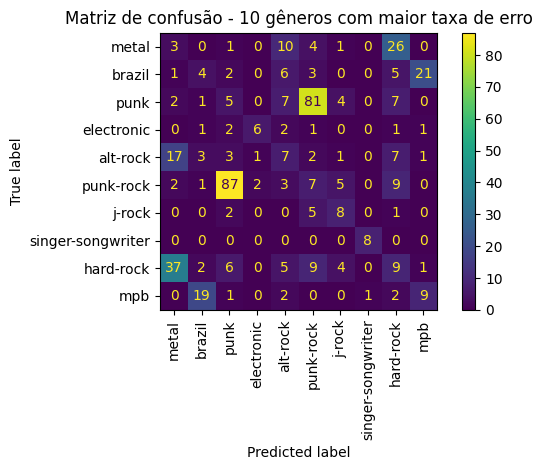

In [113]:
# Fiz a matriz apenas usando os 10 gêneros com maior taxa de erro
mask = y_test.isin(top10_generos)

ConfusionMatrixDisplay.from_predictions(
    y_test[mask],
    y_pred[mask],
    labels=top10_generos,
    xticks_rotation=90
)

plt.title("Matriz de confusão - 10 gêneros com maior taxa de erro")
plt.tight_layout()
plt.show()

### Avaliação da capacidade de generalização do modelo

Alta lacuna de generalização indica overfitting.


In [114]:
print("Avaliação da capacidade de generalização")

# f1_rf_original foi calculado anteriormente para comparar as duas versões da RF
# original e otimizada, tendo concluído que a otimizada não apresentava melhorias
# com relação à original

y_pred_train = final_model.predict(X_train)

f1_train = f1_score(
    y_train,
    y_pred_train,
    average="weighted"
)

comparacao = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "F1_weighted": [f1_train, f1_rf_original]
})

print(comparacao)
print("\nLacuna de Generalização:")
print(f1_train - f1_rf_original)

Avaliação da capacidade de generalização
  Conjunto  F1_weighted
0   Treino     0.816123
1    Teste     0.232949

Lacuna de Generalização:
0.5831743585049115


## 10.1 Análise de erros e limitações

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
- Como esperado, o modelo parece ter mais dificuldade em distiguir gêneros que não têm características estéticas muito marcantes, ou muito diferentes dos outros. Alguns gêneros são agrupamentos de músicas de um mesmo país como "brazil" ou "turkish" ou "british", o que pode indicar que um grupo de músicas muito variadas foram agrupadas sob um mesmo gênero apenas por seu país de origem. O mesmo parece acontecer com "singer-songwriter", provavelmente um gênero muito heterogêneo. REVER AQUI PQ MUDARAM OS GENEROS
- O modelo apresenta indícios de overfitting, pois obteve F1-score ponderado de aproximadamente 0,816 no conjunto de treinamento e 0,233 no conjunto de teste. Isso indica que a Random Forest conseguiu aprender muito bem os padrões presentes nos dados de treinamento, mas sua capacidade de generalização para dados não vistos é significativamente menor. Parte desse comportamento pode ser explicada pela elevada complexidade do problema (113 classes) e pela sobreposição das características acústicas entre diversos gêneros musicais.
- Como o conjunto de dados é balanceado, a acurácia também é uma métrica informativa. Entretanto, o F1-score ponderado oferece uma visão mais completa do desempenho do modelo em um problema multiclasse.
- Eu acredito que a base de dados estava bem diversificada e balanceada, mas, mesmo assim, é difícil treinar o modelo para acertar alguns gêneros musicais com base nessas características acústicas. Ele funciona melhor em alguns casos e falha muito em outros.
- Embora o modelo apresente um ganho significativo de desempenho com relação ao Dummy, ele não deve ser utilizado como sistema definitivo de classificação musical em aplicações reais, especialmente para gêneros muito semelhantes.



**Provavelmente seria necessário experimentar outras estratégias, como:**

ajustar max_features;
aumentar min_samples_leaf;
limitar mais a profundidade das árvores;
ou até utilizar outro tipo de modelo.

# 11. Comparação final dos modelos

| Modelo | Métrica principal (f1_weighted) | Accuracy | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline (DummyClassifier) | 0.000155 | 0.008850 | 0.110 | _desempenho equivalente ao acaso_ |
| KNN | 0.169879 | 0.172301 | 0.582 | _desempenho limitado para um problema com 113 classes_ |
| GaussianNB | 0.033736 | 0.059867 | 0.382 | _baixo desempenho, provavelmente porque as hipóteses de independência entre as variáveis não são atendidas_ |
| DecisionTree | 0.165997 | 0.164602 | 5.419 | _desempenho intermediário, não foi suficiente para capturar a complexidade do problema_ |
| RandomForest ESCOLHIDO | 0.232949 | 0.242788 | 116.331 | _melhor desempenho entre os modelos, escolhido como modelo final_ |
| RandomForest Otimizada | 0.225198 | 0.239602 | _não comparável_ | _a otimização não apresentou melhora no desempenho no conjunto teste_ |


O Random Forest apresentou o melhor desempenho entre os modelos avaliados, obtendo os maiores valores de Accuracy e F1-weighted. Embora tenha apresentado um tempo de treinamento significativamente maior que os demais modelos, esse custo foi considerado aceitável diante do ganho de desempenho. A otimização de hiperparâmetros produziu uma configuração ligeiramente diferente, mas não resultou em melhoria no conjunto de teste. Assim, optei por utilizar a versão original da Random Forest como modelo final.

# 12. Boas práticas e rastreabilidade

**Limitações conhecidas**

Apenas 10 atributos acústicos foram utilizados.
O problema envolve 113 classes, tornando a classificação bastante complexa.
Diversos gêneros apresentam características acústicas semelhantes.
A busca de hiperparâmetros foi reduzida (3×3) por limitações computacionais, após verificar que uma busca mais ampla (5×5) produzia resultados semelhantes.
Foi observado overfitting na Random Forest (F1 treino ≈ 0,816; F1 teste ≈ 0,233).

**Recursos computacionais usados**

Execução realizada no Google Colab (CPU), com aproximadamente 12 GB de memória RAM disponível. O treinamento da Random Forest foi a etapa de maior custo computacional.

**O que foi tentado e descartado**

Utilização de LogisticRegression (descartada por não ser adequada ao problema com muitas classes e relações não lineares).
Otimização mais extensa dos hiperparâmetros (5×5), substituída por uma busca 3×3 devido ao custo computacional semelhante e aos resultados próximos.
Uso da Random Forest otimizada como modelo final, descartado por apresentar desempenho ligeiramente inferior ao modelo original no conjunto de teste.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| SEED=42 | _garantir reprodutibilidade_ | _resultados consistentes_ |
|excluir gênero "comedy" do estudo | _maioria das faixas não era música_ | _concentrar o estudo em músicas_ |
| estudar apenas atributos acústicos | _foco na classificação com base nas características acústicas das faixas_ | _evitar vazamento de informação e reduzir a dimensionalidade_ |
| exlcuir as 4 variáveis categórias | _não apresentavam muito valor preditivo_ | _diminuir complexidade desnecessária_ |
| padronizar apenas o KNN | _KNN depende das distâncias entre amostras_ | _melhorar o desempenho do KNN sem adicionar processamento desnecessário aos outros modelos_ |
| F1-score ponderado como métrica principal | _num problema com muitas classes, a métrica considera simultaneamente precisão e revocação_ | _comparação mais representativa do desempenho dos modelos_ |
| baseline DummyClassifier "most_frequent" | _essa estratégia funciona melhor na nessa base balanceada do que "uniform"_ | _estabelecer uma referência mínima de desempenho_ |
|testar 4 modelos | _comparar abordagens com diferentes características_ | _principalmente em termos de aprendizado_ |
| busca por hiperparâmetros 3 x 3 | _foi reduzida após a busca 5 x 5 chegar a resultados semelhantes_ | _economia de tempo de processamento e recursos computacionais_ |
|manter RandomForest original | _a versão otimizada apresentou desempenho ligeiramente inferior no conjunto de teste_ | _priorizar o modelo com melhor capacidade de generalização observada_ |



# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  

O objetivo deste trabalho foi desenvolver e avaliar modelos de aprendizado de máquina para a **classificação automática de gêneros musicais a partir de atributos acústicos das faixas**. Foram comparadas diferentes abordagens de classificação, buscando identificar o modelo que apresentasse o melhor desempenho para um problema multiclasse com 113 gêneros.

Entre os modelos avaliados, a **Random Forest apresentou o melhor desempenho**, obtendo Accuracy de aproximadamente 24,3% e F1-score ponderado de 0,233, superando significativamente o baseline baseado no DummyClassifier, cujo desempenho foi próximo ao esperado para uma escolha aleatória (F1 ≈ 0,009). Isso demonstra que o modelo foi capaz de aprender padrões relevantes presentes nos atributos acústicos das músicas.

Também foi realizada uma etapa de otimização de hiperparâmetros utilizando RandomizedSearchCV. Embora a busca tenha encontrado uma configuração diferente para a Random Forest, o modelo otimizado apresentou desempenho ligeiramente inferior no conjunto de teste. Por esse motivo, optou-se por manter a versão original da Random Forest como modelo final.

Durante a avaliação observou-se uma diferença expressiva entre o desempenho no conjunto de treinamento (F1 ≈ 0,816) e no conjunto de teste (F1 ≈ 0,233), indicando **indícios de overfitting**. Esse resultado sugere que, embora o modelo aprenda bem os exemplos utilizados no treinamento, sua capacidade de **generalização é limitada**. Parte dessa limitação pode ser atribuída à elevada complexidade do problema, que envolve um grande número de classes e gêneros com características acústicas semelhantes.

Acredito que nesse trabalho enfrentei principalmente limitações pela minha falta de conhecimento na área. Optei por usar os modelos simples num primeiro momento e não buscar soluções mais rebuscadas.

Com trabalhos futuros, seria interessante explorar modelos mais sofisticados, ampliar o conjunto de atributos utilizados, investigar técnicas de redução de dimensionalidade e avaliar algoritmos de ensemble ou métodos baseados em aprendizado profundo. Também seria possível aprofundar a otimização de hiperparâmetros e investigar estratégias para reduzir o overfitting e melhorar a capacidade de generalização do modelo.